### Contexto de negócio
Temos uma base de dados de histórico de vendas de diversas empresas que atuam pela Olist, que é um ecossistema de soluções para o varejo. https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
O Objetivo deste projeto é realizar uma análise de Elasticidade de preço-demanda, a fim de trazer recomendações para o time de negócio.

### Objetivo
    Gerar recomendações baseando-se na análise da elasticidade dos preços.

<img src="https://mercadoeconsumo.com.br/wp-content/uploads/2021/04/olist-divulgalcao.jpg" width="400"/>

### Etapas da Análise

- Importação de bibliotecas e carregamento dos dados
- Limpeza, tratamento e preparação
- Cálculos elasticidade
    - Remoção sazonalidade
    - Cálculo da Elasticidade Preço-Demanda
    - Clusterização de Produtos
- Visualização de Resultados
- Conclusões 

### Estrutura das tabelas
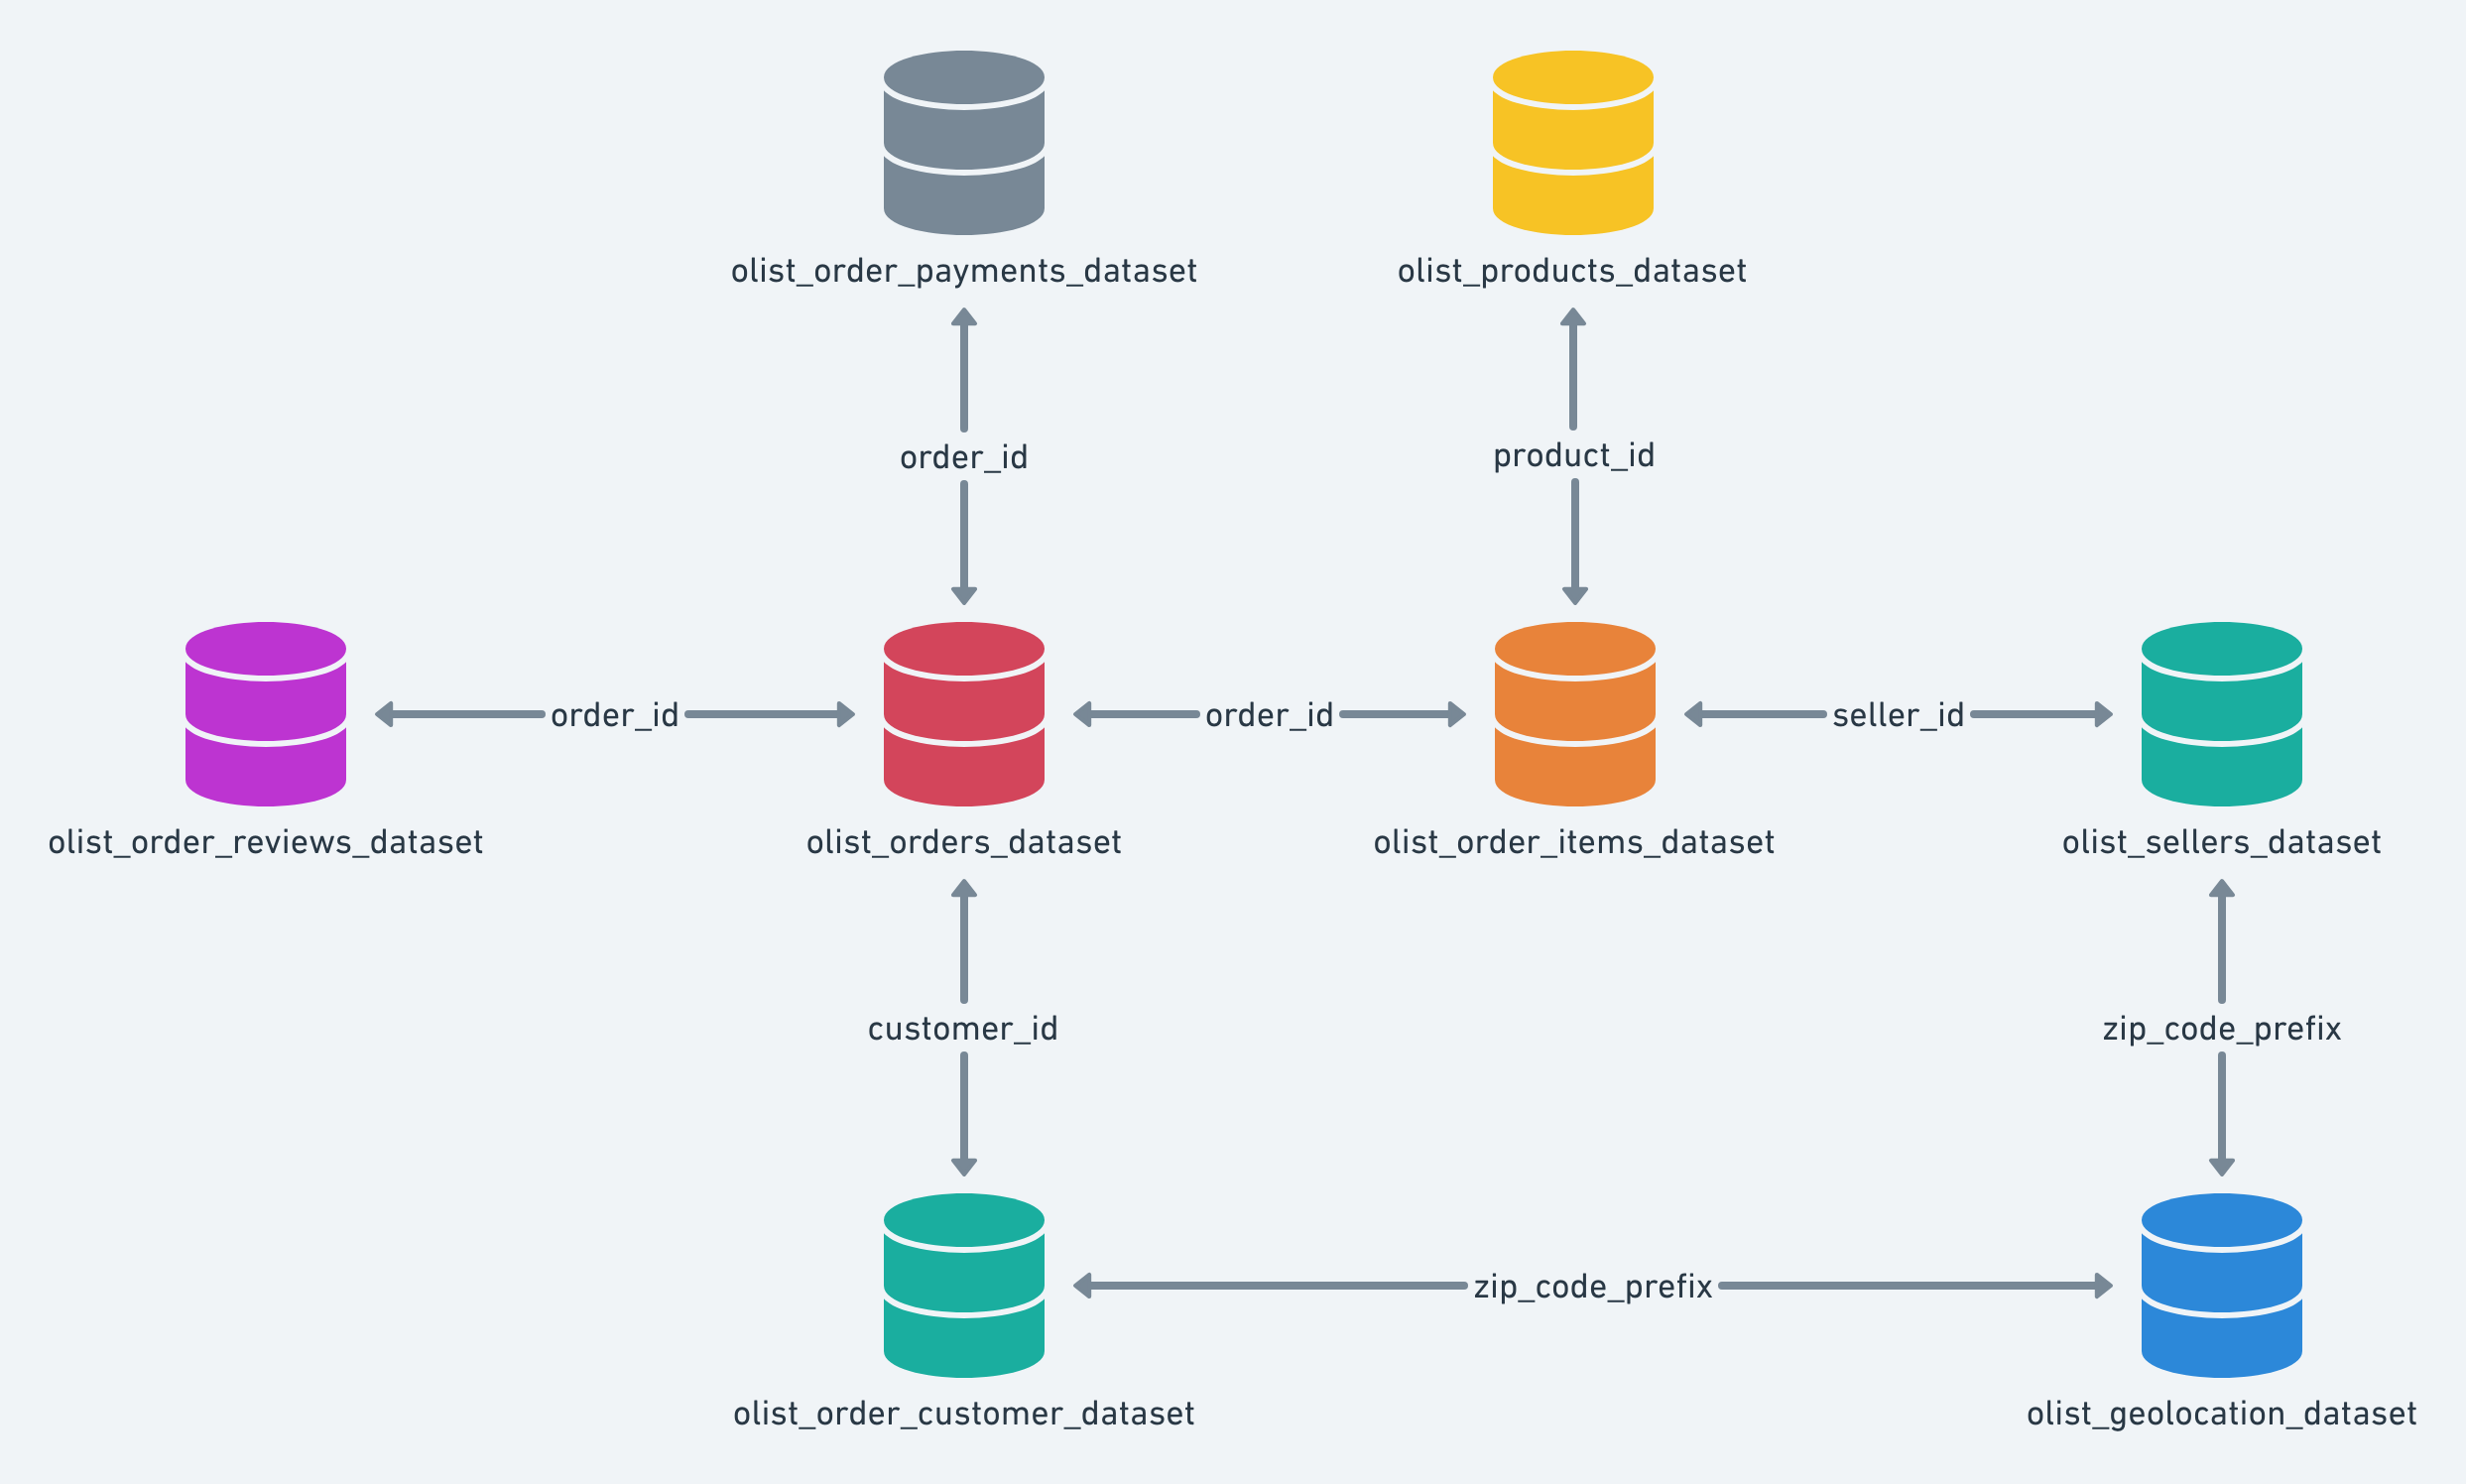

### 📖 Carregamento das bibliotecas.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from statsmodels.tsa.seasonal import STL
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [3]:
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
#print("path to dataset files: ", path)

### 🧹Limpeza, tratamento e preparação

In [4]:
path_olist = r"C:\Users\diogo\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2"
dfs = {}
for file in os.listdir(path_olist):
    name = file.replace(".csv","")
    dfs[name] = pd.read_csv(f"{path}/{file}")
    print({name})

{'olist_customers_dataset'}
{'olist_geolocation_dataset'}
{'olist_orders_dataset'}
{'olist_order_items_dataset'}
{'olist_order_payments_dataset'}
{'olist_order_reviews_dataset'}
{'olist_products_dataset'}
{'olist_sellers_dataset'}
{'product_category_name_translation'}


In [5]:
dfs["olist_products_dataset"].isnull().sum()
#dfs['olist_customers_dataset'].info()
#dfs['olist_geolocation_dataset'].info()
#dfs['olist_orders_dataset'].info()
#dfs['olist_order_items_dataset'].info()
#dfs['olist_order_payments_dataset'].info()
#dfs['olist_order_reviews_dataset'].info()
#dfs['olist_products_dataset'].info()
#dfs['olist_sellers_dataset'].info()
#dfs['product_category_name_translation'].info()

# tabelas abaixo identificadas com infos nulas, no geral não impactam o objetivo desse projeto, apenas os nulos da coluna 
# product_category_name da tabela olist_products_dataset, mas inicialmente não encontrei ref. para preencher as infos.

#olist_orders_dataset, olist_order_reviews_dataset,olist_products_dataset

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [6]:
dfs["olist_products_dataset"].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
dfs["olist_orders_dataset"].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
# Unificando as tabelas para ter em um só df, tanto pedidos quanto produtos e preços, para aplicação dos cálculos

df = pd.merge(
    dfs["olist_orders_dataset"], dfs["olist_order_items_dataset"], 
    on=['order_id','order_id'], how='left'
)
df = pd.merge(
    df, dfs["olist_products_dataset"], 
    on=['product_id','product_id'], how='left'
)

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [9]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['first_day_month'] = df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,first_day_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,2018-07-01
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,2018-08-01
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,2018-02-01


In [10]:
# df[df['order_id']=='0008288aa423d2a3f00fcb17cd7d8719'].head()
# Agrupamento por produto
df_agg = (
    df.groupby(['order_id', 'product_id','first_day_month','price'])
    .agg(qty=('product_id','count'))
    .reset_index()
    .sort_values(by='first_day_month')
)

In [11]:
# Agrupando por categoria, pois por produto encontramos pouco material histórico para calculo de elasticidade
df_agg_category = (
    df.groupby(['product_category_name','first_day_month','price'])
    .agg(qty=('product_id','count'))
    .reset_index()
    .sort_values(by='first_day_month')
)

# Criando coluna de valor, para depois agrupar e ter o preço ponderado por categoria de produto, seria errado só fazer média
df_agg_category['value'] = df_agg_category['price'] * df_agg_category['qty']

# Agrupando novamente para termos a tabela final 
df_agg_category = (
    df_agg_category.groupby(['product_category_name','first_day_month'])
    .agg({
        'qty':'sum',
        'value':'sum'
    })
    .reset_index()
    .sort_values(by='first_day_month')
)
df_agg_category['price'] = (df_agg_category['value'] / df_agg_category['qty']).round(2)
df_agg_category.head()

,product_category_name,first_day_month,qty,value,price
190,beleza_saude,2016-09-01,3,134.97,44.99
949,moveis_decoracao,2016-09-01,2,72.89,36.44
1198,telefonia,2016-09-01,1,59.50,59.50
950,moveis_decoracao,2016-10-01,67,5807.89,86.68
191,beleza_saude,2016-10-01,48,4552.51,94.84


### 🧮 Cálculos Elasticidade
- Remoção sazonalidade
- Cálculo da Elasticidade Preço-Demanda
- Análise de Elasticidade Cruzada
- Clusterização de Produtos


In [12]:
# REMOÇÃO SAZONALIDADE > é necessária para evitar distorções, como aumento preço no natal e mesmo assim vender mais.
# Utilização do metodo STL, ele adapta as infos. de qtd, removendo distorção de sazonalidade
df_agg_category.groupby('first_day_month')['first_day_month'].head() 

# Importante que tenha 2 ciclos completos, para que o metodo identifique a sazonalidade

190    2016-09-01
949    2016-09-01
1198   2016-09-01
950    2016-10-01
191    2016-10-01
          ...    
189    2018-08-01
81     2018-08-01
75     2018-08-01
93     2018-08-01
948    2018-09-01
Name: first_day_month, Length: 110, dtype: datetime64[ns]

In [13]:
def dessazonalizar(serie):
    if len(serie) < (2*12):
        return serie
    
    res = STL(serie, period=12).fit()
    return res.trend + res.resid

df_agg_category['qty_dessazonalizada'] = df_agg_category.groupby('product_category_name')['qty'].transform(dessazonalizar)

In [14]:
df_agg_category.head()

,product_category_name,first_day_month,qty,value,price,qty_dessazonalizada
190,beleza_saude,2016-09-01,3,134.97,44.99,3
949,moveis_decoracao,2016-09-01,2,72.89,36.44,2
1198,telefonia,2016-09-01,1,59.50,59.50,1
950,moveis_decoracao,2016-10-01,67,5807.89,86.68,67
191,beleza_saude,2016-10-01,48,4552.51,94.84,48


In [15]:
print(df_agg_category[df_agg_category['qty_dessazonalizada'] <= 0])


Empty DataFrame
Columns: [product_category_name, first_day_month, qty, value, price, qty_dessazonalizada]
Index: []


In [16]:
df_agg_category.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1262 entries, 190 to 948
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   product_category_name  1262 non-null   object        
 1   first_day_month        1262 non-null   datetime64[ns]
 2   qty                    1262 non-null   int64         
 3   value                  1262 non-null   float64       
 4   price                  1262 non-null   float64       
 5   qty_dessazonalizada    1262 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 69.0+ KB


In [17]:
# CÁLCULO ELASTICIDADE PREÇO-DEMANDA

# Aplicação de log para equalizar as diferenças
df_agg_category['log_price'] = np.log(df_agg_category['price'])
df_agg_category['log_qty'] = np.log(df_agg_category['qty_dessazonalizada'])

# Removendo zeros para não afetar os cálculos
df_agg_category = df_agg_category[(df_agg_category['log_price'] >0) & (df_agg_category['log_qty']) >0]

resultados = []

# Removendo produtos que tem outros pontos de analise no df
for category, grupo in df_agg_category.groupby('product_category_name'):
    if len(grupo) <5:
        continue

    if grupo['log_price'].nunique() < 2:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(grupo['log_price'], grupo['log_qty'])

    resultados.append({
        'product_category_name': category,
        'elasticidade': slope,
        'r2': r_value**2,
        'p_value': p_value
    })
df_elasticidade = pd.DataFrame(resultados)

In [18]:
df_elasticidade.head()

,product_category_name,elasticidade,r2,p_value
0,agro_industria_e_comercio,0.339616,0.226937,0.053214
1,alimentos,-0.091595,0.001489,0.875367
2,alimentos_bebidas,0.820410,0.387245,0.005819
3,artes,0.024312,0.000376,0.943188
4,artigos_de_festas,0.166452,0.049898,0.509093


In [19]:
df_confiavel = df_elasticidade[
    (df_elasticidade['p_value'] < 0.05) &
    (df_elasticidade['r2'] > 0.3)
]
print(len(df_elasticidade))
print(len(df_confiavel))

66
12


In [20]:
# Chegamos em um empasse onde temos de 436 produtos apenas 28 confiaveis (6%), conforme pesquisa pode acontecer isso nessa base de dados.
# Isso acontece pois na Olist, temos muitos vendedores, qtd alta de diversificação de produtos e portanto altas chances de ter menos histórico por produto.

# Realizei um teste fazendo esta análise por categoria, e foi possível de 66 categorias, 12 com confiança para análise (18%).

In [21]:
df_confiavel.sort_values(by='elasticidade')

# Sempre tomar cuidado com elasticidade positiva, pois em geral não faz sentido com a regra de oferta e demanda, apenas em alguns casos.
# como produtos muito essenciais que mesmo subindo preço demanda aumenta (Bem de griffen), ou no caso de Bem de luxo

# Elasticidade: é uma razão entre variação preço e quantidade x * elasticidade, sendo x a variação de preço.
# se o preço varia 10% então (consoles_games) 0.10 * -1.08 = -10,8% > para cada aumento de 10% nessa categoria, perde-se 10% de qtd vendidas

# r3: O quanto percentualmente o preço explica a variação da quantidade.
 
# p_value: indica o % da relação estar errada, então tomamos por precaução um padrão abaixo de 5%, 
# p_value < 0.05, indica que temos 95% de certeza sobre a correlação de preço/demanda, acima disso, reduzimos essa certeza.

,product_category_name,elasticidade,r2,p_value
30,esporte_lazer,-4.050516,0.373974,3.222544e-03
60,relogios_presentes,-2.983658,0.872325,6.187809e-10
37,ferramentas_jardim,-2.758589,0.722168,1.085949e-06
57,perfumaria,-1.558246,0.402346,2.013476e-03
28,eletronicos,-1.552232,0.521931,2.166933e-04
18,consoles_games,-1.089965,0.537367,1.566990e-04
48,moveis_colchao_e_estofado,-1.075712,0.675624,2.328071e-02
2,alimentos_bebidas,0.820410,0.387245,5.818665e-03
49,moveis_cozinha_area_de_servico_jantar_e_jardim,1.201068,0.504026,6.609577e-04
10,beleza_saude,4.076158,0.631463,9.993853e-06


In [22]:
# Observações para produtos com alta elasticidade:
# 1.Evitar repassar custos de forma agressiva. 
# 2.Monitorar concorrencia, pois seus clientes são sensiveis a preço, então podem procurar por substitutos.
# 3.Promoções podem trazer altos resultados devido a elasticidade.

In [31]:
# CLUSTERIZAÇÃO K-MEANS
# Transformando categoria em numero devido ao modelo não trabalhar com texto
x = pd.get_dummies(df_confiavel[['product_category_name','elasticidade', 'r2', 'p_value']],
                   columns=['product_category_name'])

# Normalizando dados (deixando na mesma escala)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Aplicando Kmeans com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df_confiavel['cluster'] = kmeans.fit_predict(x_scaled)

df_confiavel.sort_values(by=['cluster','elasticidade'])

C:\Users\diogo\AppData\Local\Temp\ipykernel_17660\1218340383.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_confiavel['cluster'] = kmeans.fit_predict(x_scaled)


,product_category_name,elasticidade,r2,p_value,cluster
30,esporte_lazer,-4.050516,0.373974,3.222544e-03,0
60,relogios_presentes,-2.983658,0.872325,6.187809e-10,0
37,ferramentas_jardim,-2.758589,0.722168,1.085949e-06,0
57,perfumaria,-1.558246,0.402346,2.013476e-03,0
28,eletronicos,-1.552232,0.521931,2.166933e-04,0
18,consoles_games,-1.089965,0.537367,1.566990e-04,0
2,alimentos_bebidas,0.820410,0.387245,5.818665e-03,0
49,moveis_cozinha_area_de_servico_jantar_e_jardim,1.201068,0.504026,6.609577e-04,0
48,moveis_colchao_e_estofado,-1.075712,0.675624,2.328071e-02,1
10,beleza_saude,4.076158,0.631463,9.993853e-06,2


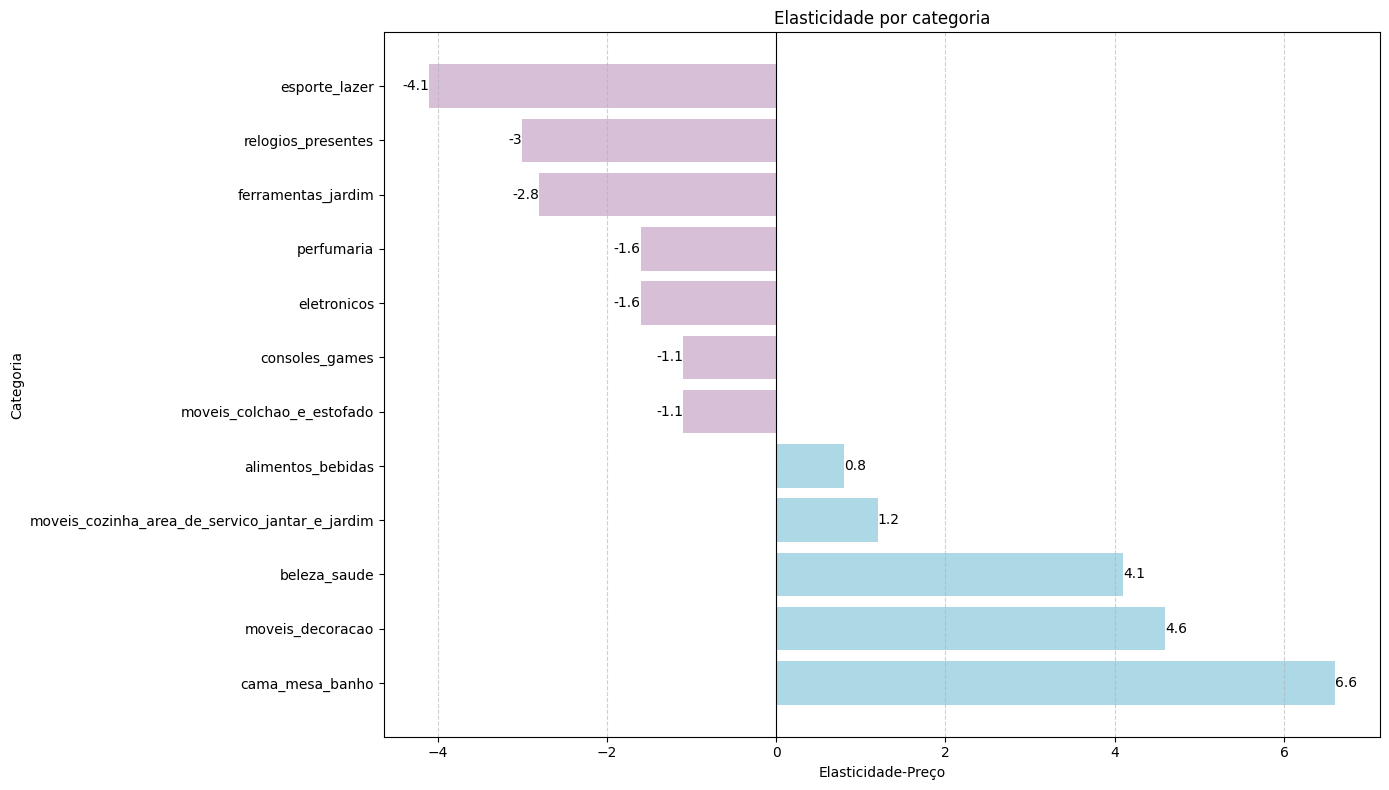

In [61]:
df_plot = df_confiavel.sort_values(by='elasticidade', ascending=False)

plt.figure(figsize=(14,8))
bars = plt.barh(df_plot['product_category_name'],df_plot['elasticidade'].round(1),
         color=['thistle' if x < 0 else 'lightblue' for x in df_plot['elasticidade'].round(1)])

plt.xlabel('Elasticidade-Preço')
plt.ylabel('Categoria')
plt.title('Elasticidade por categoria')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.6 )
plt.bar_label(container=bars)

plt.tight_layout()


#### 💡 Conclusão
#### 1. Falta de dados
Como principal alerta, devo citar a falta de quantidade de dados para a construção da análise. 
Quando realizada a análise a nível de produto, a quantidade de resultados positivos foi baixa; portanto, 
mudei a estratégia e passei a analisar por categoria. Isso se deve à insuficiência de dados históricos 
para a aplicação dos cálculos de elasticidade.

Dito isso, ainda assim prossegui e realizei a aplicação do método para a identificação de estratégias para o negócio, com os dados disponíveis.

#### 2. Elasticidade & Ações
Aplicando os cálculos de elasticidade e agrupamento, identifiquei que o Cluster '0', é onde devemos gerar ações.
Citando os grupos mais elasticos temos esporte_lazer, relogios_presentes e ferramentas_jardim, entre outros.

Nestas categorias, temos que tomar ações como:

- **Promoções**: Tendo alta elasticidade, aumento de preço facilmente quebra a demanda, portanto, promoções também aumentam a demanda.
- **Cross-Selling**: Utilizar estes produtos como atração, para também vender outros relacionados.
- **Segmentação de clientes**: Quais são os clientes que mais compram produtos de alta elasticidade? utilizar essa lista para direcionar vendas.

#### PRÓXIMOS PASSOS: 
Deixo como orientação, como próximos passos, o acompanhamento das ações a serem realizadas, a fim de avaliar sua eficiência, bem como compreender a efetividade dos resultados das análises deste projeto.